In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import torch
from torch_geometric.data import Data
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [11]:
import glob

In [21]:
bprna_files = glob.glob('/Users/elimeyers/ribozyme/data/unzipped/bpRNA_1m_90_STAFILES/*.st')

In [36]:
set(rna_seq[1])

{'(', ')', '.'}

In [40]:
all_db = set()
for f in bprna_files:
    with open(f, 'r') as f:
        rna_seq = f.readlines()
    rna_seq = [rna_seq[i].rstrip('\n') for i in range(len(rna_seq)) if rna_seq[i][0] != '#']
    db = set(rna_seq[1])
    if 'A' in db:
        print(f)
        print(rna_seq[1])


<_io.TextIOWrapper name='/Users/elimeyers/ribozyme/data/unzipped/bpRNA_1m_90_STAFILES/bpRNA_PDB_650.st' mode='r' encoding='UTF-8'>
((((((.([({((.(((((..<<.<<))))))(.A.).]}..(((((>>()>>.))))).))a).))))))
<_io.TextIOWrapper name='/Users/elimeyers/ribozyme/data/unzipped/bpRNA_1m_90_STAFILES/bpRNA_PDB_544.st' mode='r' encoding='UTF-8'>
[[[[...{[{((((({(.(((((((((((.((((((<..)..)))))(((((((<.AAAAAA.)))))))((((((.((((.(((((.(((((((..))))))))))))..]}.{)))).))))))((((((((((((.((...))...(.((.....([((..(((((((((((((((((((.].]]]].)))))).))))>aaaaaa....)))))))))..)))...)).))))))...)))))))>.))))))))))))}}})))))(((((((((..)))))))))..(.(((((.((.(.(((.(....).))).)))))))).)((.(((.((((....)))))())).)).(((((((((((((..))))..))))))))).................................
<_io.TextIOWrapper name='/Users/elimeyers/ribozyme/data/unzipped/bpRNA_1m_90_STAFILES/bpRNA_PDB_647.st' mode='r' encoding='UTF-8'>
[[[[{((((({(.(((((((((((.((((((<..)..)))))(((((((<AAAAAAA.)))))))(((((..(((((((((((((((((..))))))))))))..]})[)))

In [38]:
all_db

{'(', ')', '.', '<', '>', 'A', '[', ']', 'a', '{', '}'}

In [70]:
bprna_files[0]

'/Users/elimeyers/ribozyme/data/unzipped/bpRNA_1m_90_STAFILES/bpRNA_RFAM_25193.st'

In [76]:
with open(bprna_files[1000], 'r') as f:
    rna_seq = f.readlines()
rna_seq = [rna_seq[i].rstrip('\n') for i in range(len(rna_seq)) if rna_seq[i][0] != '#']
rna_seq


['CGACCUCAGAUCAGACGAGACAACCCGCUGAAUUUAAGCAUAUUACUAAGCGGAGGAAAAGAAACUAACAAGGAUUCCCUCAGUAAGCGGCGAGCGAAGAGGGAAGAGCCCAGCGCCGAAUCCCCGCCCGGCGGUCGGGCGCGGGAAAAUGUGGCGUACGGAAGUCUGCUUGCCCGGCGGCGGCAGGGGGGCCUGAGUCCUUCUGAUAGAGGCUCUGCCCGUAGACAGGUGUGAGGACCGGUCAAAGGCUCCCGUCGCGCCGGGGUCCGGUCUUCUCGGUAGUCGGGUUGUUUGUGAAUGCAGCCCAAAGCGGGUGGUAAACUCCAUCUAAGGCUAAAUACCGGCGCGAGACCGAUAGCCGACAAGUACCUUAAGGGAAAGUUGAAAAGAACUUUGAAGAGAGAGUUCAACAGGGCGUGAAACCGUUGAGAGGUAAACCGGUGGGGUCCGCGCAGUCUGCGCGGGGGAUUCAGCUCCGGGGCUCGGUCGGUCGCUUGGUGCGCGGGUGGAGGGGGGUCUCCUCCUUCCCCGCCGCCUCGCUGGCCCGUGCCUUCUCCGGGGUGCACUUCCUCCGUGGCGGUGCGCCGCGACCGGCUCCUGUUCGGCUUGGAAAGGCUCGGGGCGAAGGUGGCCCGCGGCGCGAGCCGCGUGCUUUACAGCGCCCCCUGGCCCGUACCUCGCCGCUUCCGGGGGCCGUGGACUUAGUACUCGCUGCGCCCUCUCUCCCCGCGGGGAGGGACGGGGCCCCCCGCUCCCGGCGUGGCUGUCGAGCGGGGCGGACUGUUCUCAGUGCGCCCCAACCGCGUCGCGUCGCCCGGGCGGGGAUCGGCUCUCGUAAAAGGCGUCAGGGGUCUGCGGCGAUGUCGGCAACCCACCGGACCCGUCUUGAAACACGGACCAAGGAGUCUAACGCGUGCGCGAGUCAGAGGGUGGUUACGAAACCCCGUGGCGCAAUGAAAGUGAGGGCCGGCGCGCGCCGGCCGAGGUGGGAUCCCGGC

In [25]:
def string_to_pyg_graph(s):
    """
    Create a PyTorch Geometric graph from a string.
    Each character becomes a node with its ASCII value as node feature.
    Edges connect adjacent characters (sequential graph).
    
    Args:
        s: Input string
        
    Returns:
        Data: PyG Data object with nodes and edges
    """
    n = len(s)
    
    # Create node features: each node has the ASCII value of its character
    # Shape: [num_nodes, 1]
    node_features = torch.tensor([[ord(c)] for c in s], dtype=torch.float)
    
    # Create edges: connect each character to the next one (sequential)
    # This creates a linear chain: 0->1, 1->2, 2->3, ..., n-2->n-1
    edge_index = torch.tensor([
        list(range(n-1)),  # source nodes
        list(range(1, n))  # target nodes
    ], dtype=torch.long)
    
    # Store the original string characters as node data
    # This can be accessed via data.node_chars
    data = Data(x=node_features, edge_index=edge_index)
    data.node_chars = list(s)
    
    return data


In [ ]:
def add_feature(graph, feature):
    feature = feature.split(' ')
    if len


In [47]:
def connect_from_db(graph, db):
    pairs = {')':'(', ']':'[', '>':'<', 'a':'A'}
    stack = {'(':[], '[':[], '<':[]}
    for i, c in enumerate[str](db):
        if c in stack:
            stack[c].append(i)
        elif c in pairs:
            if len(stack[pairs[c]]) == 0:
                raise ValueError('Unmatched closing bracket')
            start = stack[pairs[c]].pop()
            graph.edge_index = torch.cat([graph.edge_index, torch.tensor([[start, i], [i, start]], dtype=torch.long)], dim=1)
    for c in stack:
        if len(stack[c]) != 0:
            raise ValueError('Unmatched opening bracket')
    return graph


In [78]:
# Example usage
example_string = rna_seq[0]
graph = string_to_pyg_graph(example_string)
graph = connect_from_db(graph, rna_seq[1])

print(f"Number of nodes: {graph.x.shape[0]}")
print(f"Node features shape: {graph.x.shape}")
print(f"Edge index shape: {graph.edge_index.shape}")
print(f"Node characters: {graph.node_chars}")
print(f"Node features (ASCII values): {graph.x.squeeze().tolist()}")
print(f"Edges: {graph.edge_index.t().tolist()}")


Number of nodes: 3937
Node features shape: torch.Size([3937, 1])
Edge index shape: torch.Size([2, 5668])
Node characters: ['C', 'G', 'A', 'C', 'C', 'U', 'C', 'A', 'G', 'A', 'U', 'C', 'A', 'G', 'A', 'C', 'G', 'A', 'G', 'A', 'C', 'A', 'A', 'C', 'C', 'C', 'G', 'C', 'U', 'G', 'A', 'A', 'U', 'U', 'U', 'A', 'A', 'G', 'C', 'A', 'U', 'A', 'U', 'U', 'A', 'C', 'U', 'A', 'A', 'G', 'C', 'G', 'G', 'A', 'G', 'G', 'A', 'A', 'A', 'A', 'G', 'A', 'A', 'A', 'C', 'U', 'A', 'A', 'C', 'A', 'A', 'G', 'G', 'A', 'U', 'U', 'C', 'C', 'C', 'U', 'C', 'A', 'G', 'U', 'A', 'A', 'G', 'C', 'G', 'G', 'C', 'G', 'A', 'G', 'C', 'G', 'A', 'A', 'G', 'A', 'G', 'G', 'G', 'A', 'A', 'G', 'A', 'G', 'C', 'C', 'C', 'A', 'G', 'C', 'G', 'C', 'C', 'G', 'A', 'A', 'U', 'C', 'C', 'C', 'C', 'G', 'C', 'C', 'C', 'G', 'G', 'C', 'G', 'G', 'U', 'C', 'G', 'G', 'G', 'C', 'G', 'C', 'G', 'G', 'G', 'A', 'A', 'A', 'A', 'U', 'G', 'U', 'G', 'G', 'C', 'G', 'U', 'A', 'C', 'G', 'G', 'A', 'A', 'G', 'U', 'C', 'U', 'G', 'C', 'U', 'U', 'G', 'C', 'C', 'C', 'G

## viz func

In [58]:
def visualize_graph(graph, max_nodes=None, figsize=(20, 12), layout='circular'):
    """
    Visualize a PyG graph with structure and color coding.
    
    Args:
        graph: PyG Data object
        max_nodes: Maximum number of nodes to display (None for all)
        figsize: Figure size tuple
        layout: 'circular', 'linear', or 'spring'
    """
    # Convert PyG graph to NetworkX
    G = nx.Graph()
    
    # Add nodes with labels
    num_nodes = graph.x.shape[0]
    for i in range(num_nodes):
        char = graph.node_chars[i] if hasattr(graph, 'node_chars') else str(i)
        G.add_node(i, label=char)
    
    # Separate sequential edges from base-pairing edges
    edge_index = graph.edge_index.cpu().numpy()
    sequential_edges = []
    pairing_edges = []
    
    # First, identify sequential edges (i -> i+1)
    sequential_set = set()
    for i in range(num_nodes - 1):
        sequential_set.add((i, i+1))
        sequential_set.add((i+1, i))
    
    # Categorize edges
    for i in range(edge_index.shape[1]):
        src, dst = int(edge_index[0, i]), int(edge_index[1, i])
        G.add_edge(src, dst)
        if (src, dst) in sequential_set or (dst, src) in sequential_set:
            sequential_edges.append((src, dst))
        else:
            pairing_edges.append((src, dst))
    
    # If graph is too large, show a subset
    if max_nodes and num_nodes > max_nodes:
        print(f"Graph has {num_nodes} nodes. Showing first {max_nodes} nodes for visualization.")
        nodes_to_show = list(range(max_nodes))
        G = G.subgraph(nodes_to_show).copy()
        sequential_edges = [(s, d) for s, d in sequential_edges if s < max_nodes and d < max_nodes]
        pairing_edges = [(s, d) for s, d in pairing_edges if s < max_nodes and d < max_nodes]
    
    # Create layout based on choice
    if layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'linear':
        # Linear layout: nodes in sequence order
        pos = {i: (i, 0) for i in G.nodes()}
    else:  # spring
        pos = nx.spring_layout(G, k=2, iterations=100)
    
    # Color mapping for nucleotides
    color_map = {
        'A': '#FF6B6B',  # Red
        'U': '#4ECDC4',  # Teal
        'G': '#FFE66D',  # Yellow
        'C': '#95E1D3',  # Light green
    }
    
    # Get node colors
    node_colors = []
    for i in sorted(G.nodes()):
        char = G.nodes[i]['label']
        node_colors.append(color_map.get(char, '#CCCCCC'))  # Gray for other chars
    
    # Draw the graph
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw base-pairing edges first (so they're behind)
    if pairing_edges:
        pairing_G = nx.Graph()
        pairing_G.add_edges_from(pairing_edges)
        nx.draw_networkx_edges(pairing_G, pos, ax=ax, 
                              edge_color='purple', width=2, alpha=0.6, 
                              style='dashed', label='Base-pairing')
    
    # Draw sequential edges
    if sequential_edges:
        seq_G = nx.Graph()
        seq_G.add_edges_from(sequential_edges)
        nx.draw_networkx_edges(seq_G, pos, ax=ax, 
                              edge_color='gray', width=1.5, alpha=0.4,
                              style='solid', label='Sequential')
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                          node_color=node_colors, 
                          node_size=800, 
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=1.5)
    
    # Add labels
    labels = {i: G.nodes[i]['label'] for i in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, 
                           font_size=10, font_weight='bold',
                           font_color='black')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FF6B6B', label='A (Adenine)'),
        Patch(facecolor='#4ECDC4', label='U (Uracil)'),
        Patch(facecolor='#FFE66D', label='G (Guanine)'),
        Patch(facecolor='#95E1D3', label='C (Cytosine)'),
        plt.Line2D([0], [0], color='gray', linewidth=1.5, label='Sequential edges'),
        plt.Line2D([0], [0], color='purple', linewidth=2, linestyle='--', label='Base-pairing edges'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    ax.set_title(f"RNA Graph Visualization ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)\n"
                f"Sequential: {len(sequential_edges)}, Base-pairing: {len(pairing_edges)}", 
                fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return G


## rest

In [59]:
import networkx as nx
import matplotlib.pyplot as plt

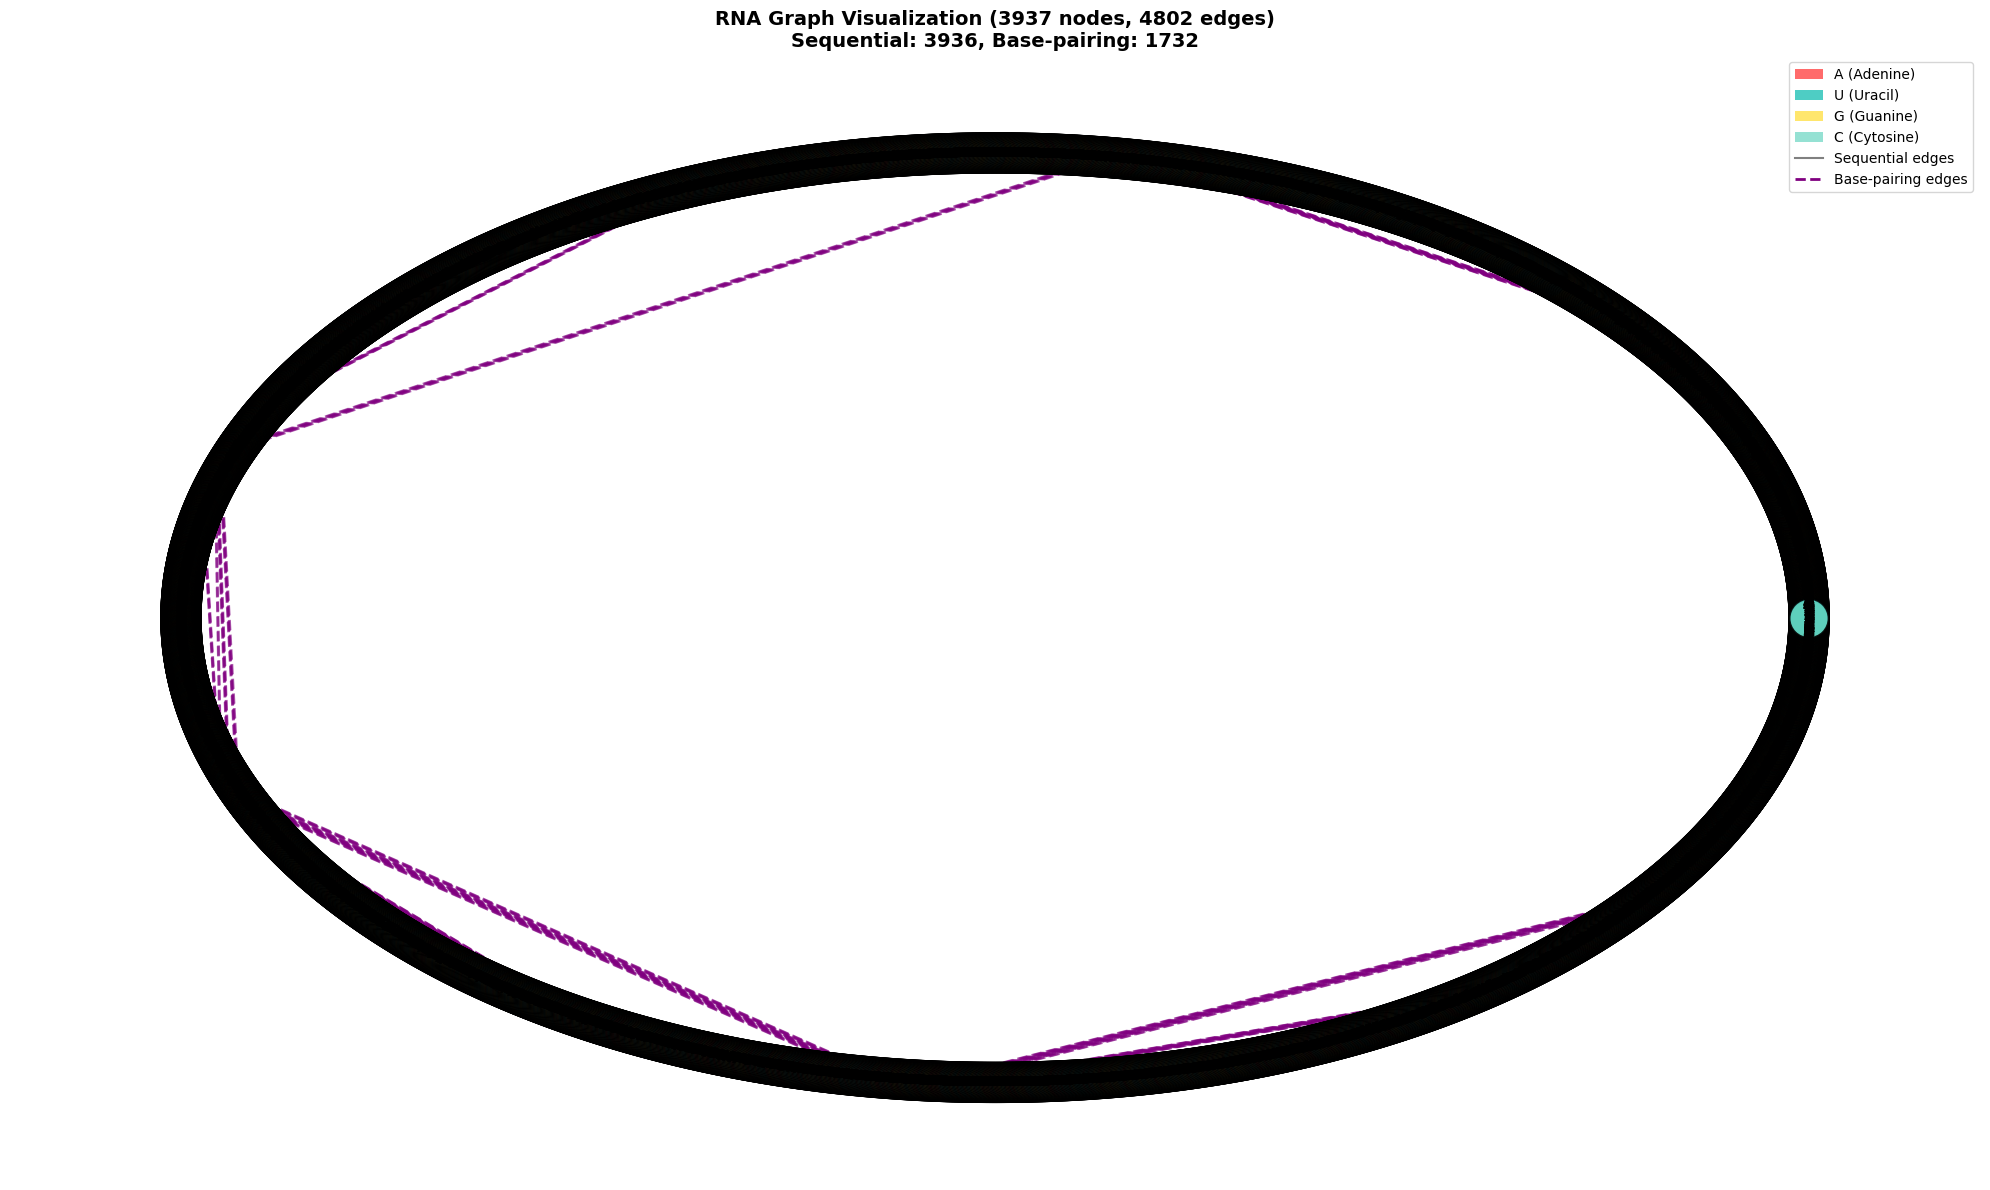

In [81]:
# Visualize the graph with structure and colors
# Try different layouts: 'circular', 'linear', or 'spring'
visualize_graph(graph)#, max_nodes=50000, layout='circular')


In [ ]:
# Linear layout - shows the sequence structure more clearly
visualize_graph(graph, max_nodes=50, layout='linear')


In [ ]:
# Spring layout - shows base-pairing relationships
visualize_graph(graph, max_nodes=50, layout='spring')
